# From ECG to HR and simple HRV (Principles: vagal tone, RSA)

## TODOs

1. Compute RMSSD and HF power during baseline vs stress masks. 
2. Describe which increases/decreases and why (vagal withdrawal during stress → lower RMSSD/HF).

## My notes

+ RMSSD (Root Mean Square of Successive Differences)
    - Calculate using the R-peaks, where these R-peaks are the heartbeats.
    - R-peaks come from ECG, where ECG has P-wave, QRS-complex, and T-wave.
    - Time domain.
    - Steps:
        1. From the ECG, detect the components: P-wave, QRS-complex, and T-wave. 
        2. Delineate ECG for R-peaks, where these R-peaks are the heartbeats
        3. Calculate RMSSD by passing in R-peaks to get HRV
            - 3.1 1 R-peak = 1 Heartbeat
            - 3.2 Consecutive R-peaks are RR-interval = consecutive HBs
                - 3.2.1  From RR-interval, calculate LF/HF
    - We want this value to be
        1. high bc it leads to better recovery + more ANS stimulaton?
            - high means more time between heartbeats
        2. varied bc it leads to better recovery
+ HF (High Frequency) power
    1. Frequency domain.
    2. Favors parasympathetic activity, which is rest and recovery/digest.
    3. We want this value to be high bc...

## Code

In [ ]:
import os
import pickle

import numpy as np
import pandas as pd

import neurokit2 as nk

import matplotlib.pyplot as plt

from tqdm import tqdm

from scipy.interpolate import interp1d
from scipy.signal import find_peaks, welch
from adtk.data import validate_series
from adtk.detector import ThresholdAD

notebook_dir = os.getcwd()

## Load Data

In [ ]:
data_path = os.path.join(notebook_dir, "../../../data/WESAD/all_subjects/chest.csv")
df = pd.read_csv(data_path)
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

In [ ]:
def get_per_subject(df):
    per_subject = {}
    entries = df['subject'].unique()
    for entry in entries:
        filt_subject = (df['subject'] == entry)
        subject_df = df[filt_subject]
        subject_df.reset_index(inplace=True)
        per_subject[entry] = subject_df
    return per_subject

In [ ]:
per_subject_dfs = get_per_subject(df)
per_subject_dfs

In [ ]:
s_df = per_subject_dfs['S7']
s_df

In [ ]:
subset_data = False

if subset_data == True:
    # subset_data_N = 126000
    subset_data_N = 21000
    series = s_df.loc[:subset_data_N, "ECG"]
    print(len(series), series)
else:
    series = s_df.loc[:, "ECG"].values
    print(len(series), series)


In [ ]:
cleaned_series = nk.ecg_clean(series, 700)
cleaned_series

In [ ]:
n_segments = 87
segments = np.array_split(cleaned_series, n_segments)
len(segments[0])

In [ ]:
segments_df = pd.DataFrame(segments)
segments_df

- > Each row represents a segment, so 174 rows = 174 segments
- > Each segment has a lenght of 21073
- > We want to compare across segments

In [ ]:
segments_df.iloc[2, :].plot.line()

In [ ]:
r_peaks_data = []
for idx, segment in tqdm(segments_df.iterrows()):
    if idx == 0: 
        # print(segment)
        segment.plot.line()
        r_peaks_in_segment = nk.ecg_peaks(segment, sampling_rate=700, show=True)
        r_peaks_data.append(r_peaks_in_segment)
    if idx > 0:
        r_peaks_in_segment = nk.ecg_peaks(segment, sampling_rate=700)
        r_peaks_data.append(r_peaks_in_segment)

len(r_peaks_data)

- Why do we have to pass in df of 0s and 1s and not their actual values?

In [42]:
def get_rmssd(df): 
    rmssd_value = df.HRV_RMSSD
    # print(rmssd_value)
    return rmssd_value

In [48]:
rmssds = []
for r_peaks_data_idx in range(len(r_peaks_data)):
    r_peaks_df, r_peaks_info = r_peaks_data[r_peaks_data_idx]
    # if r_peaks_data_idx == 1:
        # print(r_peaks_info)
        
    stats_df = nk.hrv(r_peaks_df, sampling_rate=700, show=False)
    rmssd = get_rmssd(stats_df)
    rmssds.append(rmssd)

rmssds_df = pd.DataFrame(rmssds)
rmssds_df

/Users/detraviousjamaribrinkley/Documents/Development/research_labs/roeh_labs/health/closed_loop_wearable_therapies/lamina/lamina/.venv/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/detraviousjamaribrinkley/Documents/Development/research_labs/roeh_labs/health/closed_loop_wearable_therapies/lamina/lamina/.venv/lib/python3.11/site-packages/neurokit2/hrv/hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/Users/detraviousjamaribrinkley/Documents/Developm

,0
HRV_RMSSD,53.003915
HRV_RMSSD,84.277994
HRV_RMSSD,91.260678
HRV_RMSSD,43.795611
HRV_RMSSD,43.520713
...,...
HRV_RMSSD,129.502871
HRV_RMSSD,129.643591
HRV_RMSSD,86.228504
HRV_RMSSD,81.799149


> r_peaks are 1 and non-r_peaks = 0

<Axes: >

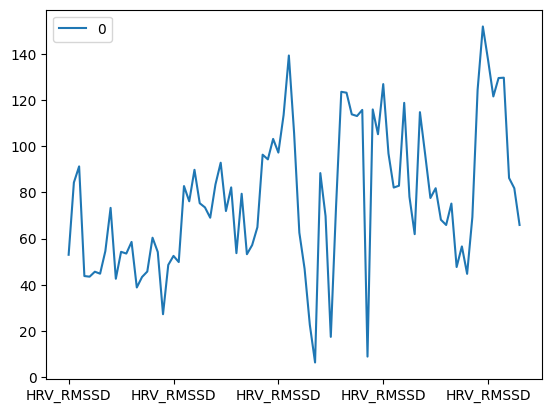

In [50]:
rmssds_df.plot.line()

In [ ]:
r_peak_values = segments_df.iloc[0, r_peaks_info['ECG_R_Peaks']].values
r_peak_values

In [ ]:
# nk.hrv(r_peak_values, sampling_rate=700, show=True)
stats_0_df = nk.hrv(r_peaks_df, sampling_rate=700, show=True)
stats_0_df

In [ ]:
def get_rmssd(df): 
    rmssd_value = df.HRV_RMSSD
    # print(rmssd_value)
    return rmssd_value


In [ ]:
stats_0_rmssd = get_rmssd(stats_0_df)
stats_0_rmssd

In [ ]:
r_peaks_1_df, r_peaks_1_info = r_peaks_data[1]
r_peaks_1_info

In [ ]:
stats_1_df = nk.hrv(r_peaks_1_df, sampling_rate=700, show=True)
stats_1_df
stats_1_rmssd = get_rmssd(stats_1_df)
stats_1_rmssd

In [ ]:
rmssd_df = pd.DataFrame([stats_0_rmssd.values, stats_1_rmssd])
rmssd_df

In [ ]:
rmssd_df.plot.line()

## Follow-Up

> - Be sure to see TODOs

1. What do we gather from this subject?
2. Is there anything to flag?
3. 'RMSSD_ms': np.float64(698.4470516017469)
    - Why?
    - Good/Bad?
4. 'HF': np.float64(0.04114562090390898), why?
    - Why?
    - Good/Bad?
5. RMSSD_ms and HF considered jointly
    - If one is good and other bad? Vice versa
    - If both are good? Both are bad?

### 1. What do we gather from this subject?

> - R-peaks (aka heartbeats in green).


In [ ]:
# Could say something based on the avg of the window of 60 secs or take last

# Choose sampling rate and adjustable
# 